# Import the Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Import the Dataset

In [4]:
df = pd.read_csv('retail_data.csv')

# Exploratory Data Analysis

In [6]:
df.head()

,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,...,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products
0,8691788.0,37249.0,Michelle Harrington,Ebony39@gmail.com,1.414787e+09,3959 Amanda Burgs,Dortmund,Berlin,77985.0,Germany,...,324.086270,Clothing,Nike,Shorts,Excellent,Same-Day,Debit Card,Shipped,5.0,Cycling shorts
1,2174773.0,69749.0,Kelsey Hill,Mark36@gmail.com,6.852900e+09,82072 Dawn Centers,Nottingham,England,99071.0,UK,...,806.707815,Electronics,Samsung,Tablet,Excellent,Standard,Credit Card,Processing,4.0,Lenovo Tab
2,6679610.0,30192.0,Scott Jensen,Shane85@gmail.com,8.362160e+09,4133 Young Canyon,Geelong,New South Wales,75929.0,Australia,...,1063.432799,Books,Penguin Books,Children's,Average,Same-Day,Credit Card,Processing,2.0,Sports equipment
3,7232460.0,62101.0,Joseph Miller,Mary34@gmail.com,2.776752e+09,8148 Thomas Creek Suite 100,Edmonton,Ontario,88420.0,Canada,...,2466.854021,Home Decor,Home Depot,Tools,Excellent,Standard,PayPal,Processing,4.0,Utility knife
4,4983775.0,27901.0,Debra Coleman,Charles30@gmail.com,9.098268e+09,5813 Lori Ports Suite 269,Bristol,England,48704.0,UK,...,248.553049,Grocery,Nestle,Chocolate,Bad,Standard,Cash,Shipped,1.0,Chocolate cookies


In [7]:
df.shape

(302010, 30)

### There are 302010 rows and 30 columns

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302010 entries, 0 to 302009
Data columns (total 30 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction_ID    301677 non-null  float64
 1   Customer_ID       301702 non-null  float64
 2   Name              301628 non-null  object 
 3   Email             301663 non-null  object 
 4   Phone             301648 non-null  float64
 5   Address           301695 non-null  object 
 6   City              301762 non-null  object 
 7   State             301729 non-null  object 
 8   Zipcode           301670 non-null  float64
 9   Country           301739 non-null  object 
 10  Age               301837 non-null  float64
 11  Gender            301693 non-null  object 
 12  Income            301720 non-null  object 
 13  Customer_Segment  301795 non-null  object 
 14  Date              301651 non-null  object 
 15  Year              301660 non-null  float64
 16  Month             30

### There are 10 numerical variables and 20 string/categorical variables and there are some null values

In [11]:
df.isnull().sum()

Transaction_ID      333
Customer_ID         308
Name                382
Email               347
Phone               362
Address             315
City                248
State               281
Zipcode             340
Country             271
Age                 173
Gender              317
Income              290
Customer_Segment    215
Date                359
Year                350
Month               273
Time                350
Total_Purchases     361
Amount              357
Total_Amount        350
Product_Category    283
Product_Brand       281
Product_Type          0
Feedback            184
Shipping_Method     337
Payment_Method      297
Order_Status        235
Ratings             184
products              0
dtype: int64

In [13]:
df.duplicated().sum()

4

### There are 4 duplicate records which will be removed in the next step

In [15]:
df.drop_duplicates(inplace=True)

### Before removing amount and total purchases, the null values of total amount will be replaced by the value obtained from multiplying total purchases and amount if both of them are not null

In [17]:
df['Total_Amount'] = np.where(
    (df['Total_Purchases'].isna()) | (df['Amount'].isna()),
    df['Total_Amount'], 
    df['Total_Purchases'] * df['Amount']
)

In [18]:
df['Total_Amount'].isnull().sum()

1

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302006 entries, 0 to 302009
Data columns (total 30 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction_ID    301673 non-null  float64
 1   Customer_ID       301698 non-null  float64
 2   Name              301624 non-null  object 
 3   Email             301659 non-null  object 
 4   Phone             301644 non-null  float64
 5   Address           301691 non-null  object 
 6   City              301758 non-null  object 
 7   State             301725 non-null  object 
 8   Zipcode           301666 non-null  float64
 9   Country           301735 non-null  object 
 10  Age               301833 non-null  float64
 11  Gender            301689 non-null  object 
 12  Income            301716 non-null  object 
 13  Customer_Segment  301791 non-null  object 
 14  Date              301647 non-null  object 
 15  Year              301656 non-null  float64
 16  Month             301733 

### The datatypes of customer id and year will be converted to object

In [21]:
df['Customer_ID'] = df['Customer_ID'].astype(object)
df['Year'] = df['Year'].astype(object)

### The datatype of the date will be converted to date format

In [23]:
df['Date'] = pd.to_datetime(df['Date'],format='mixed')

In [24]:
plt.rcParams['figure.figsize'] = [20,10]

## Outlier Detection

In [26]:
num = df.select_dtypes(include=np.number).columns.to_list()
iqr = df[num].quantile(0.75) - df[num].quantile(0.25)
upper_limit = df[num].quantile(0.75) + iqr * 1.5 
lower_limit = df[num].quantile(0.25) - iqr * 1.5
outliers = df[((df[num] > upper_limit) | (df[num] < lower_limit)).any(axis=1)]
outliers.shape

(3905, 30)

## There are 3905 outlier rows

## Univariate Analysis

In [29]:
df[['Age','Total_Amount','Ratings']].describe()

,Age,Total_Amount,Ratings
count,301833.000000,302005.000000,301822.000000
mean,35.481034,1367.659743,3.162685
std,15.021812,1128.989267,1.320822
min,18.000000,10.003750,1.000000
25%,22.000000,438.743806,2.000000
50%,32.000000,1041.133812,3.000000
75%,46.000000,2029.988051,4.000000
max,70.000000,4999.625796,5.000000


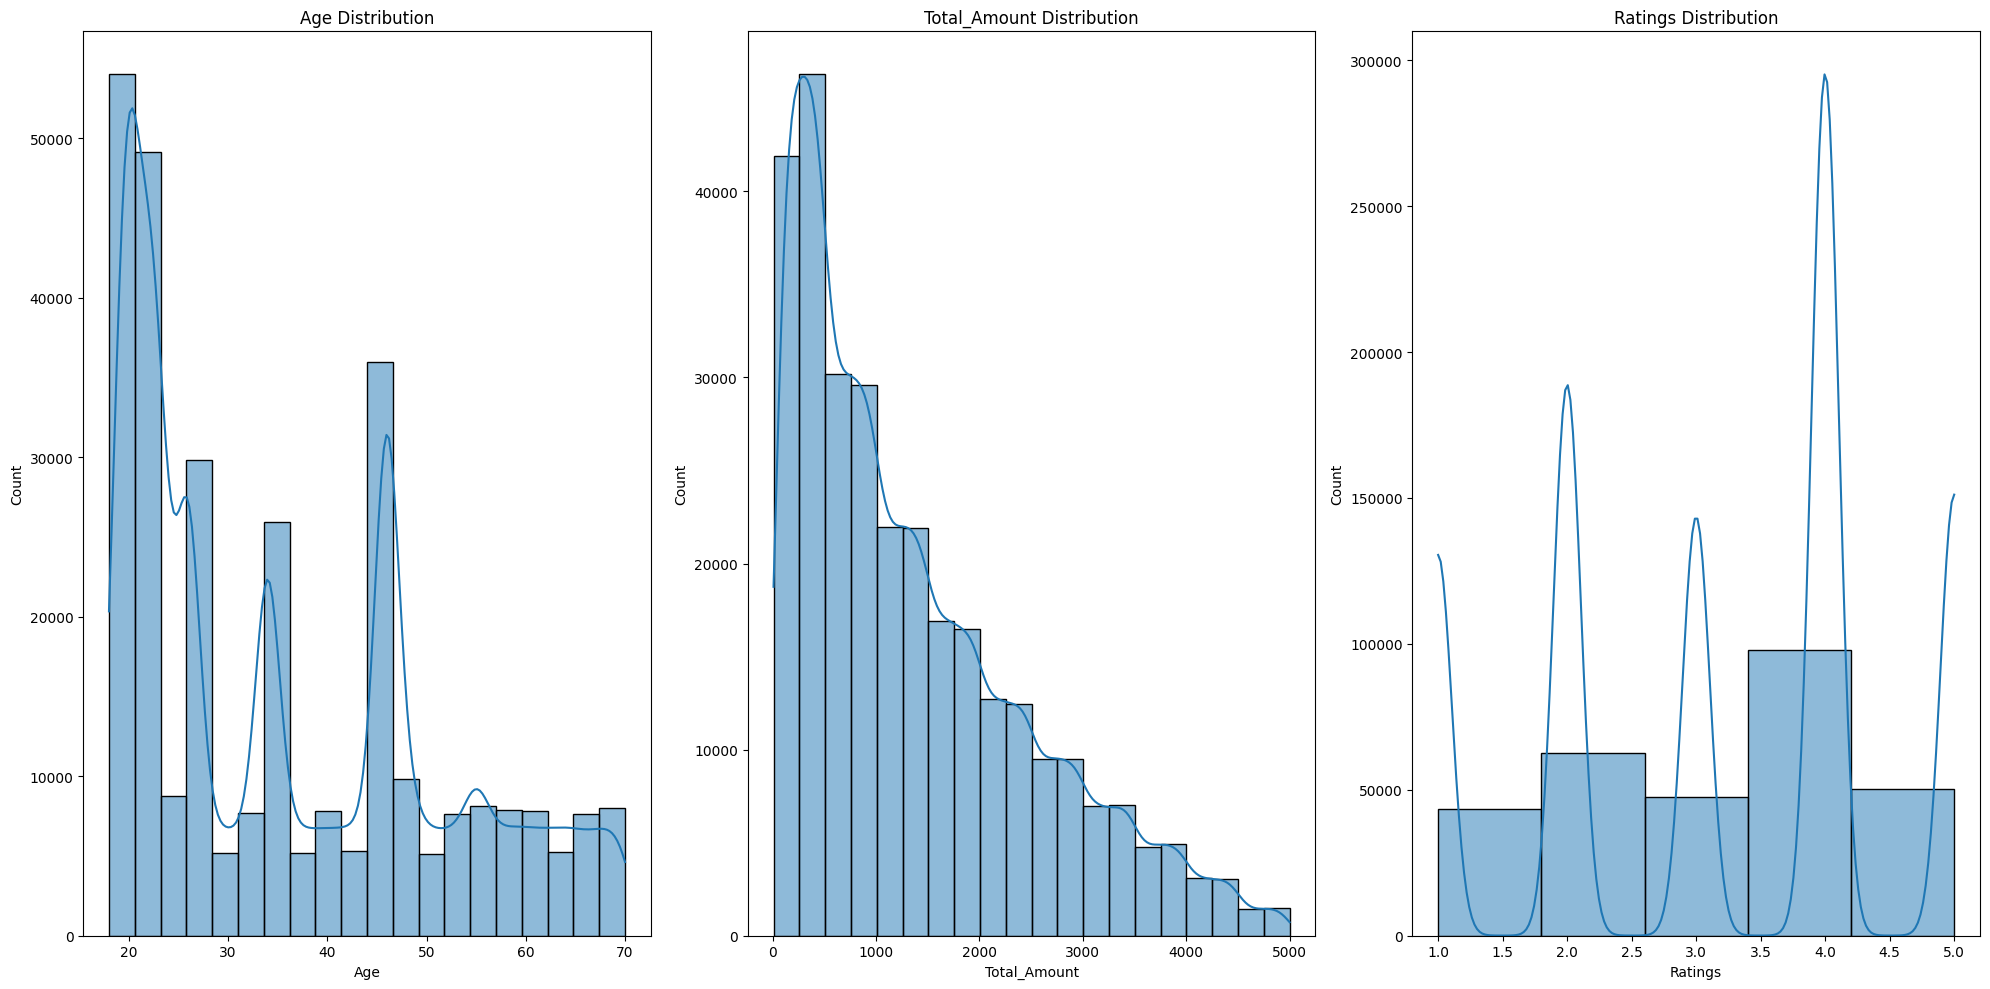

In [30]:
plot_dict = {'Age': 20, 'Total_Amount': 20, 'Ratings': 5}
t = 1
for col, bins in plot_dict.items():
    plt.subplot(1,3,t)
    sns.histplot(data=df, x=col, bins=bins, kde=True)
    plt.title(f'{col} Distribution')
    t += 1
plt.tight_layout()
plt.show()

### The average age of customers is around 35
### Age is within the range [18,70]
### Age seems to be right skewed

### The average amount spend by customers is around 1368 per purchase
### Total amount is within the range [10,5000)
### Total amount seems to be right skewed

### The average ratings is around 3
### Ratings is within the range [1,5]
### Ratings seems to be slightly right skewed

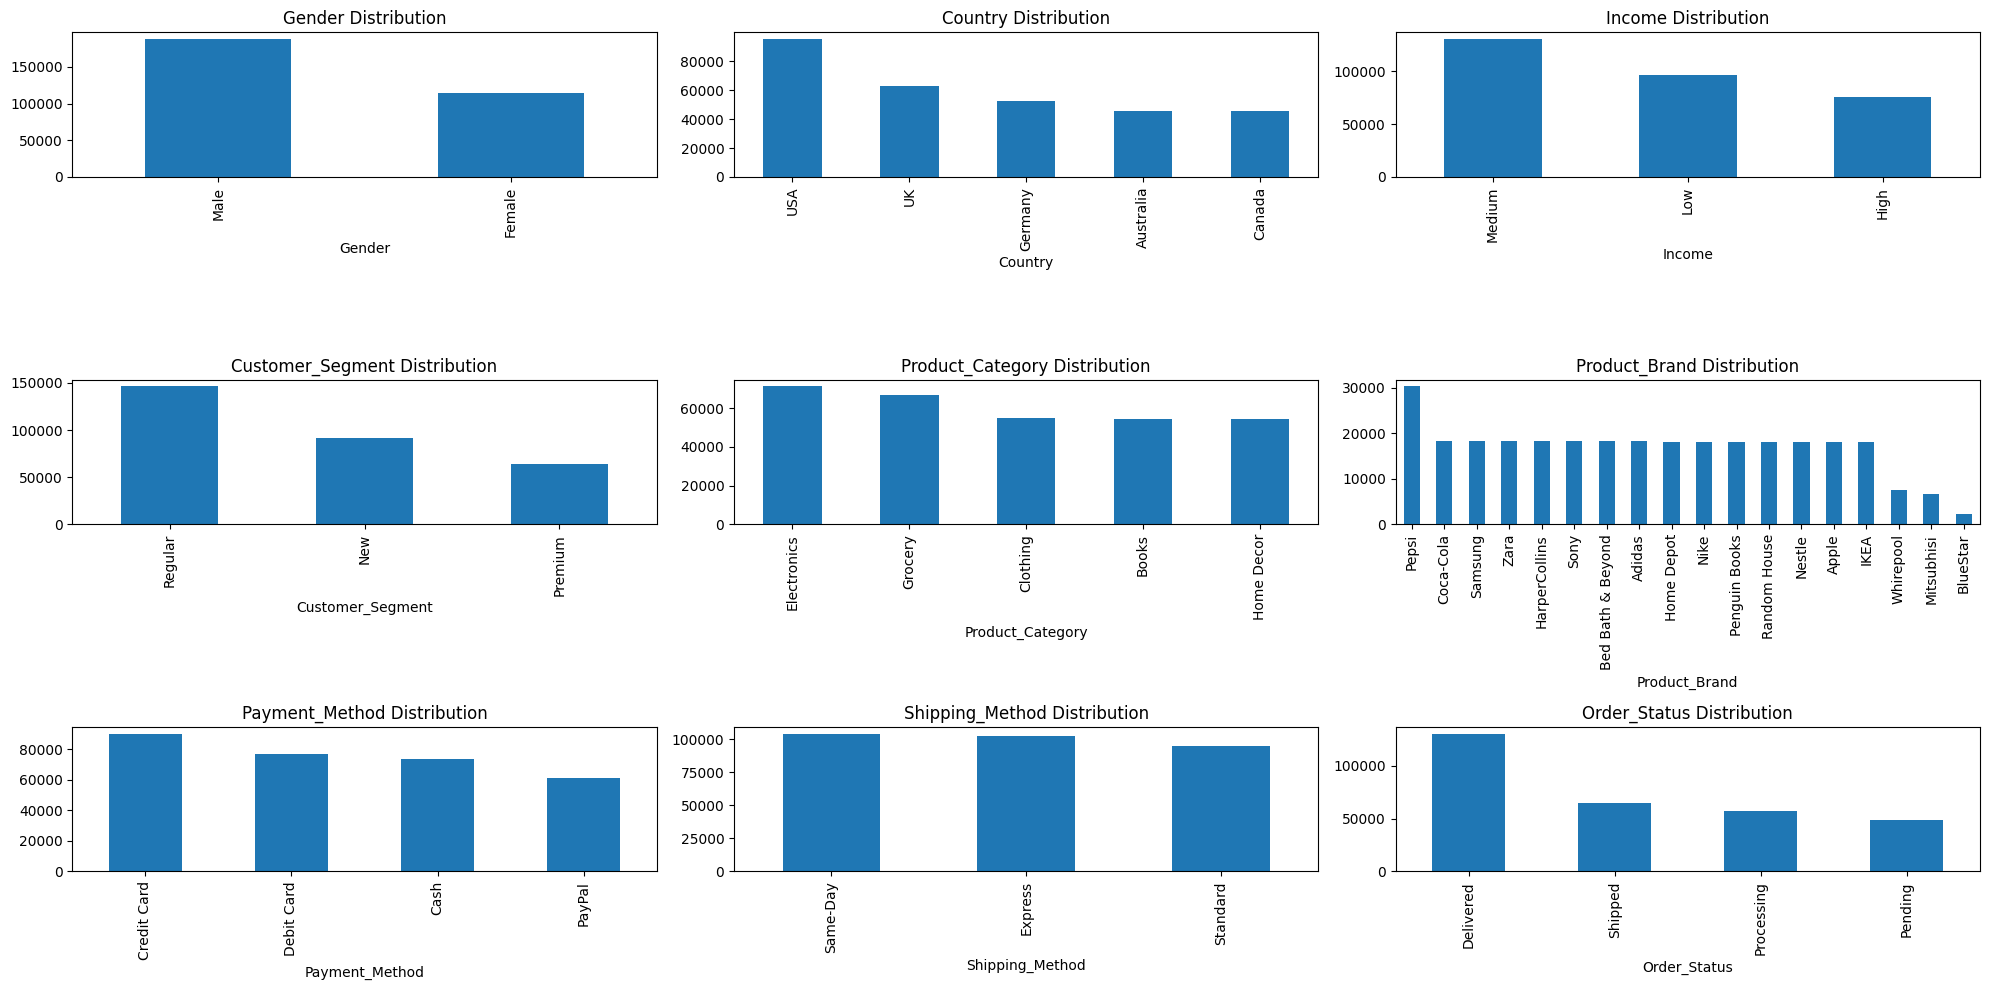

In [34]:
categorical_vars = ['Gender', 'Country', 'Income','Customer_Segment', 'Product_Category', 
                   'Product_Brand', 'Payment_Method', 'Shipping_Method', 'Order_Status']
t = 1
for col in categorical_vars:
    plt.subplot(3, 3, t)
    df[col].value_counts().plot(kind='bar')
    plt.title(f'{col} Distribution')
    plt.xticks(rotation=90)
    t += 1
plt.tight_layout()
plt.show()

### The customers from USA have ordered the most and the customers from canada have ordered the least
### Male customers have ordered more than female customers
### Customers from medium income bracket have ordered the most and customers from high income bracket have ordered the least
### Regular customers have ordered the most and Premium customers have ordered the least
### Electronics Products have been ordered the most whereby home decor products have been ordered the least
### Pepsi Brand has seen the most orders whereas bluestar brand has seen the least orders
### Majority of the customers have opted for same day shipping
### Majority of the customers have chosen credit card has their payment method

## Bivariate Analysis

In [37]:
num = df.select_dtypes(include=np.number).columns.to_list()

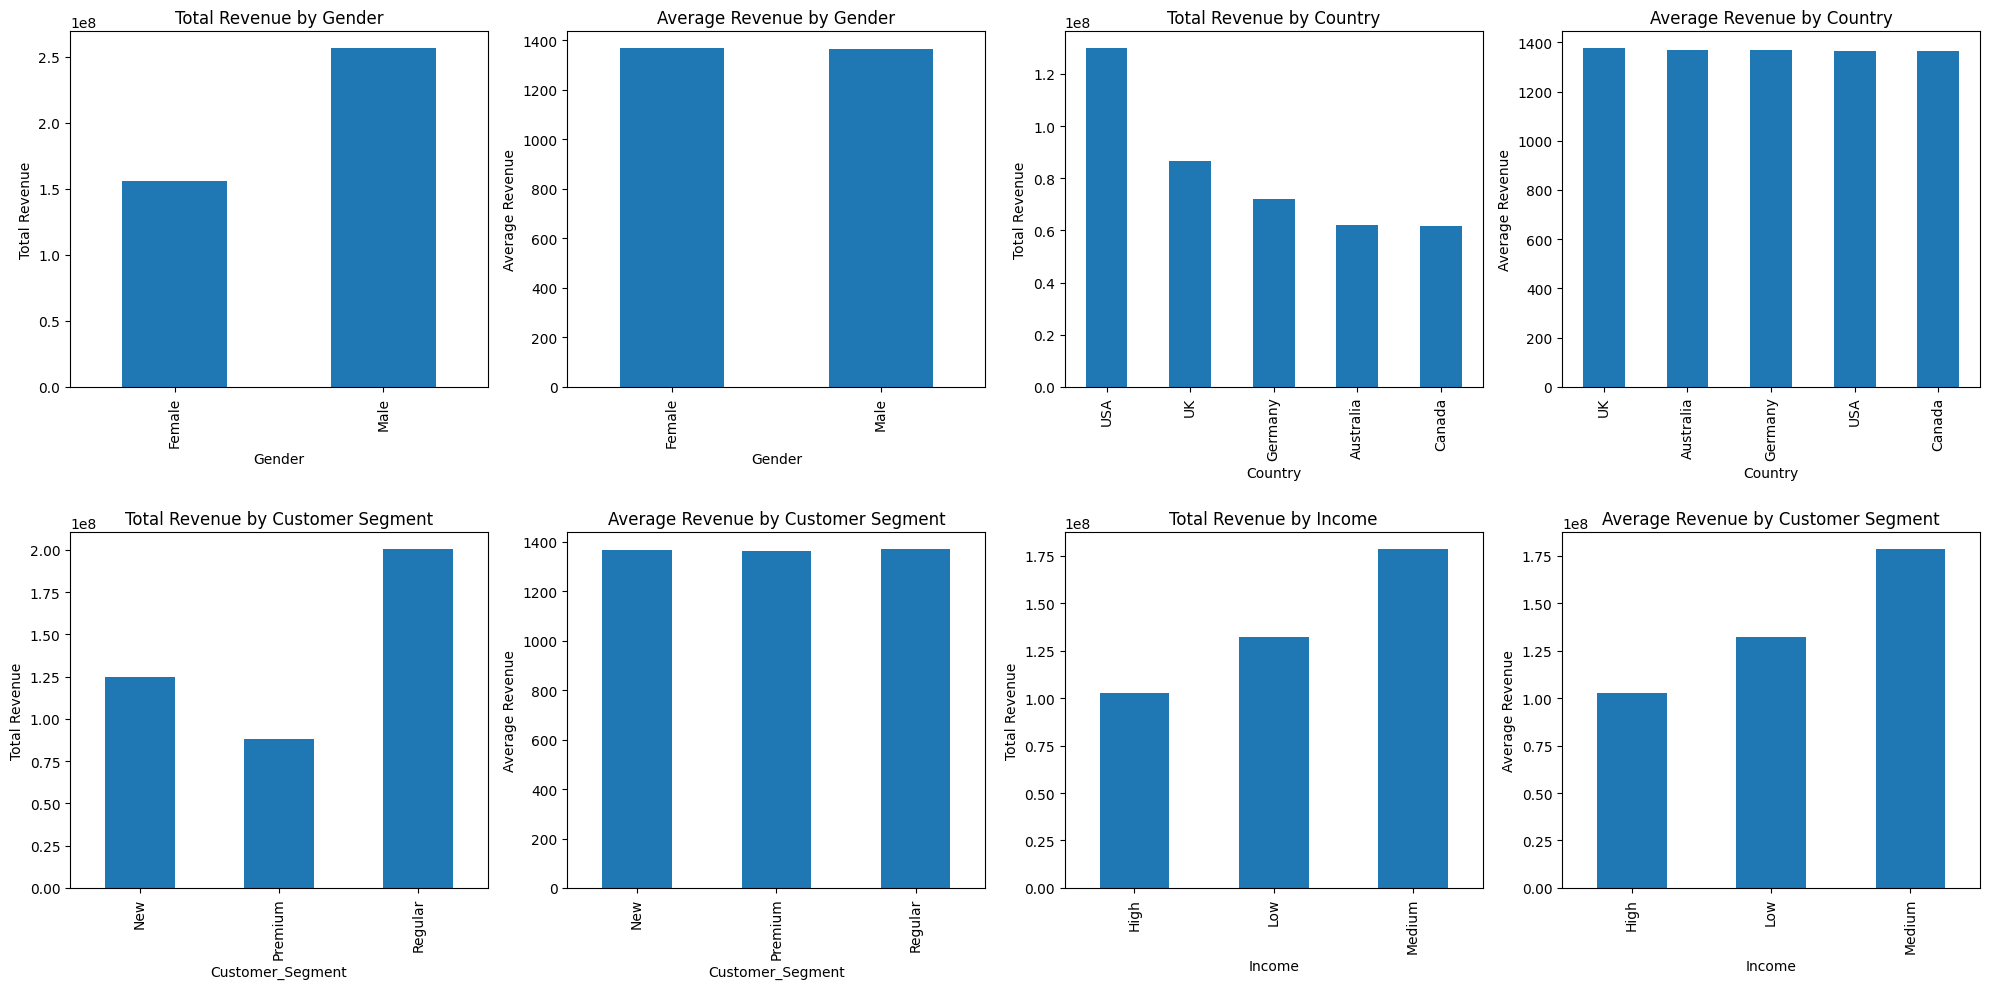

In [38]:
plt.subplot(2, 4, 1)
df.groupby('Gender')['Total_Amount'].sum().plot(kind='bar')
plt.title('Total Revenue by Gender')
plt.ylabel('Total Revenue')

plt.subplot(2, 4, 2)
df.groupby('Gender')['Total_Amount'].mean().plot(kind='bar')
plt.title('Average Revenue by Gender')
plt.ylabel('Average Revenue')

# Revenue by Country
plt.subplot(2, 4, 3)
df.groupby('Country')['Total_Amount'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Total Revenue by Country')
plt.ylabel('Total Revenue')

plt.subplot(2, 4, 4)
df.groupby('Country')['Total_Amount'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Average Revenue by Country')
plt.ylabel('Average Revenue')

# Revenue by Customer Segment
plt.subplot(2, 4, 5)
df.groupby('Customer_Segment')['Total_Amount'].sum().plot(kind='bar')
plt.title('Total Revenue by Customer Segment')
plt.ylabel('Total Revenue')

plt.subplot(2, 4, 6)
df.groupby('Customer_Segment')['Total_Amount'].mean().plot(kind='bar')
plt.title('Average Revenue by Customer Segment')
plt.ylabel('Average Revenue')

# Revenue by Income
plt.subplot(2, 4, 7)
df.groupby('Income')['Total_Amount'].sum().plot(kind='bar')
plt.title('Total Revenue by Income')
plt.ylabel('Total Revenue')

plt.subplot(2, 4, 8)
df.groupby('Income')['Total_Amount'].sum().plot(kind='bar')
plt.title('Average Revenue by Customer Segment')
plt.ylabel('Average Revenue')

plt.tight_layout()
plt.show()

### USA has generated the most revenue and Canada has generated the least revenue

### Regular Customers have spent the most and Premium Customers have spent the least

### Customers from Medium level Income have spent the most and Customers from High level Income have spent the least

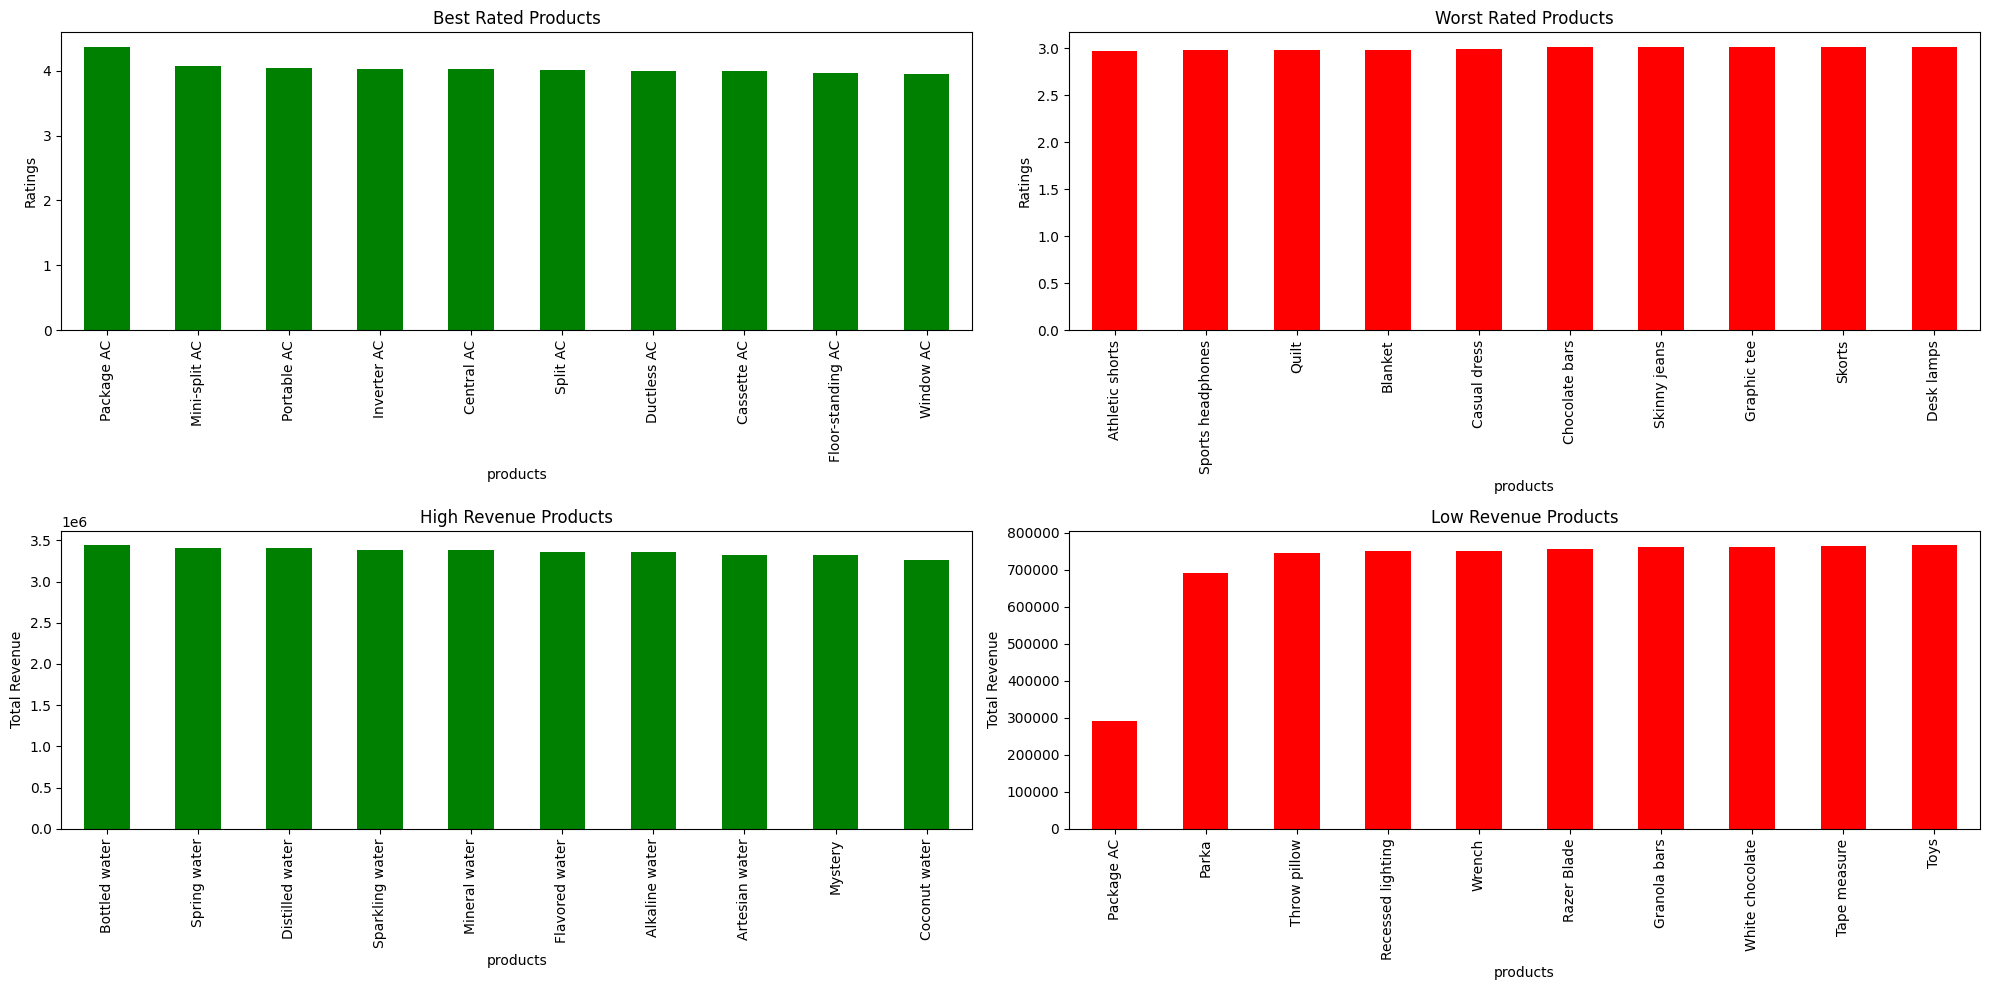

In [43]:
# Product Analysis
plt.subplot(2, 2, 1)
df.groupby('products')['Ratings'].mean().sort_values(ascending=False).head(10).plot(kind='bar',color='green')
plt.title('Best Rated Products')
plt.ylabel('Ratings')

plt.subplot(2, 2, 2)
df.groupby('products')['Ratings'].mean().sort_values(ascending=True).head(10).plot(kind='bar',color='red')
plt.title('Worst Rated Products')
plt.ylabel('Ratings')

plt.subplot(2, 2, 3)
df.groupby('products')['Total_Amount'].sum().sort_values(ascending=False).head(10).plot(kind='bar',color='green')
plt.title('High Revenue Products')
plt.ylabel('Total Revenue')

plt.subplot(2, 2, 4)
df.groupby('products')['Total_Amount'].sum().sort_values(ascending=True).head(10).plot(kind='bar',color='red')
plt.title('Low Revenue Products')
plt.ylabel('Total Revenue')

plt.tight_layout()
plt.show()

### Best rated products are all AC products

### Water Products have generated the most revenue

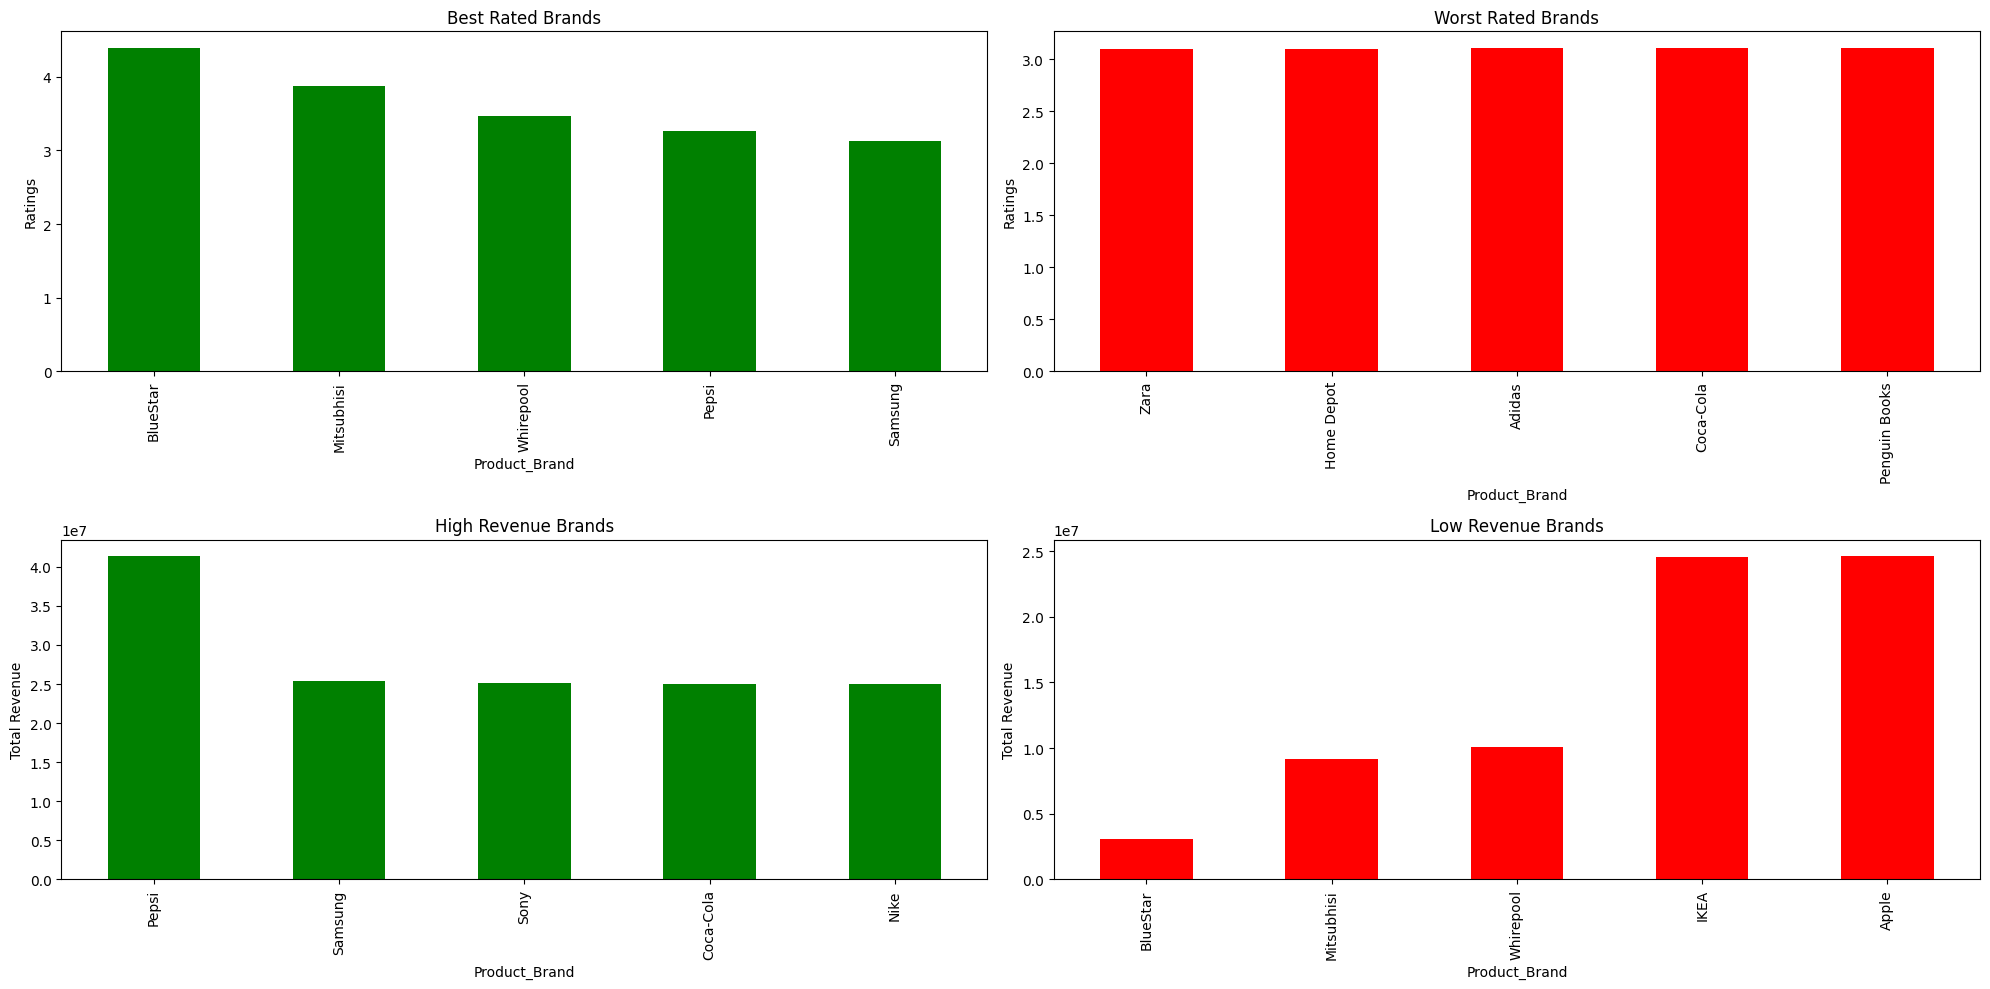

In [46]:
# Brand Analysis
plt.subplot(2, 2, 1)
df.groupby('Product_Brand')['Ratings'].mean().sort_values(ascending=False).head(5).plot(kind='bar',color='green')
plt.title('Best Rated Brands')
plt.ylabel('Ratings')

plt.subplot(2, 2, 2)
df.groupby('Product_Brand')['Ratings'].mean().sort_values(ascending=True).head(5).plot(kind='bar',color='red')
plt.title('Worst Rated Brands')
plt.ylabel('Ratings')

plt.subplot(2, 2, 3)
df.groupby('Product_Brand')['Total_Amount'].sum().sort_values(ascending=False).head(5).plot(kind='bar',color='green')
plt.title('High Revenue Brands')
plt.ylabel('Total Revenue')

plt.subplot(2, 2, 4)
df.groupby('Product_Brand')['Total_Amount'].sum().sort_values(ascending=True).head(5).plot(kind='bar',color='red')
plt.title('Low Revenue Brands')
plt.ylabel('Total Revenue')

plt.tight_layout()
plt.show()

### BlueStar,Mitsubhishi,Whirepool has high rating and low sales
### Pepsi,Samsung has high rating and high sales
### Coca-Cola has high rating and low sales

## Multivariate Analysis

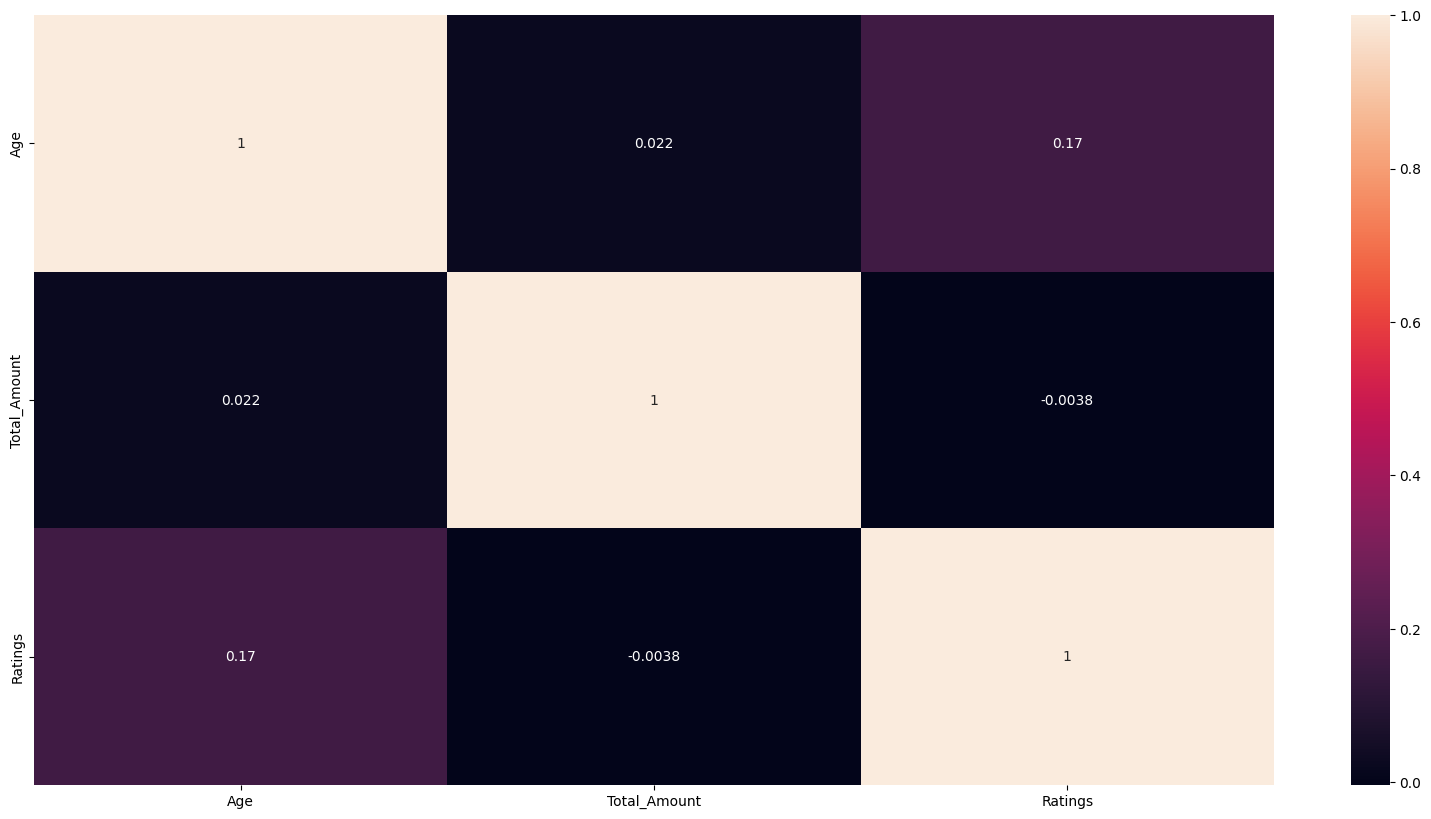

In [49]:
sns.heatmap(df[['Age','Total_Amount','Ratings']].corr(),annot=True)
plt.show()

### There is hardly any correlation among the numerical variables

In [51]:
df = df.dropna()

In [52]:
# RFM ANALYSIS PREPARATION
current_date = df['Date'].max() + pd.Timedelta(days=1)
rfm_df = df.groupby('Customer_ID').agg({
    'Date': lambda x: (current_date - x.max()).days,
    'Transaction_ID': 'count', 
    'Total_Amount': 'sum',
}).reset_index()
rfm_df.columns = ['Customer_ID', 'Recency', 'Frequency', 'Monetary']

# Merge RFM metrics with original dataset
df_with_rfm = df.merge(rfm_df, on='Customer_ID', how='left')

In [53]:
rfm_df.head()

,Customer_ID,Recency,Frequency,Monetary
0,10000.0,103,4,5007.566359
1,10001.0,105,5,8136.462822
2,10002.0,95,5,4104.013951
3,10003.0,228,2,2340.496446
4,10004.0,31,2,2356.516683


In [54]:
# RFM SCORING AND SEGMENTATION
# Create RFM scores
df_with_rfm['R_Score'] = pd.qcut(df_with_rfm['Recency'], 4, labels=[4, 3, 2, 1])
df_with_rfm['F_Score'] = pd.qcut(df_with_rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
df_with_rfm['M_Score'] = pd.qcut(df_with_rfm['Monetary'].rank(method='first'), 4, labels=[1, 2, 3, 4])

# Convert scores to numeric
df_with_rfm['R_Score'] = df_with_rfm['R_Score'].astype(int)
df_with_rfm['F_Score'] = df_with_rfm['F_Score'].astype(int)
df_with_rfm['M_Score'] = df_with_rfm['M_Score'].astype(int)

# Calculate RFM total score
df_with_rfm['RFM_Score'] = df_with_rfm['R_Score'] + df_with_rfm['F_Score'] + df_with_rfm['M_Score']

# Create RFM segments
def segment_customer(row):
    if row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return 'Champions'
    elif row['R_Score'] >= 3 and row['F_Score'] >= 3:
        return 'Loyal Customers'
    elif row['R_Score'] >= 4:
        return 'Promising'
    elif row['R_Score'] >= 2 and row['F_Score'] >= 2:
        return 'Potential Loyalists'
    elif row['R_Score'] >= 3 and row['F_Score'] <= 2:
        return 'New Customers'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk'
    elif row['R_Score'] <= 2 and row['F_Score'] <= 2:
        return 'Lost Customers'
    else:
        return 'Others'

df_with_rfm['RFM_Segment'] = df_with_rfm.apply(segment_customer, axis=1)

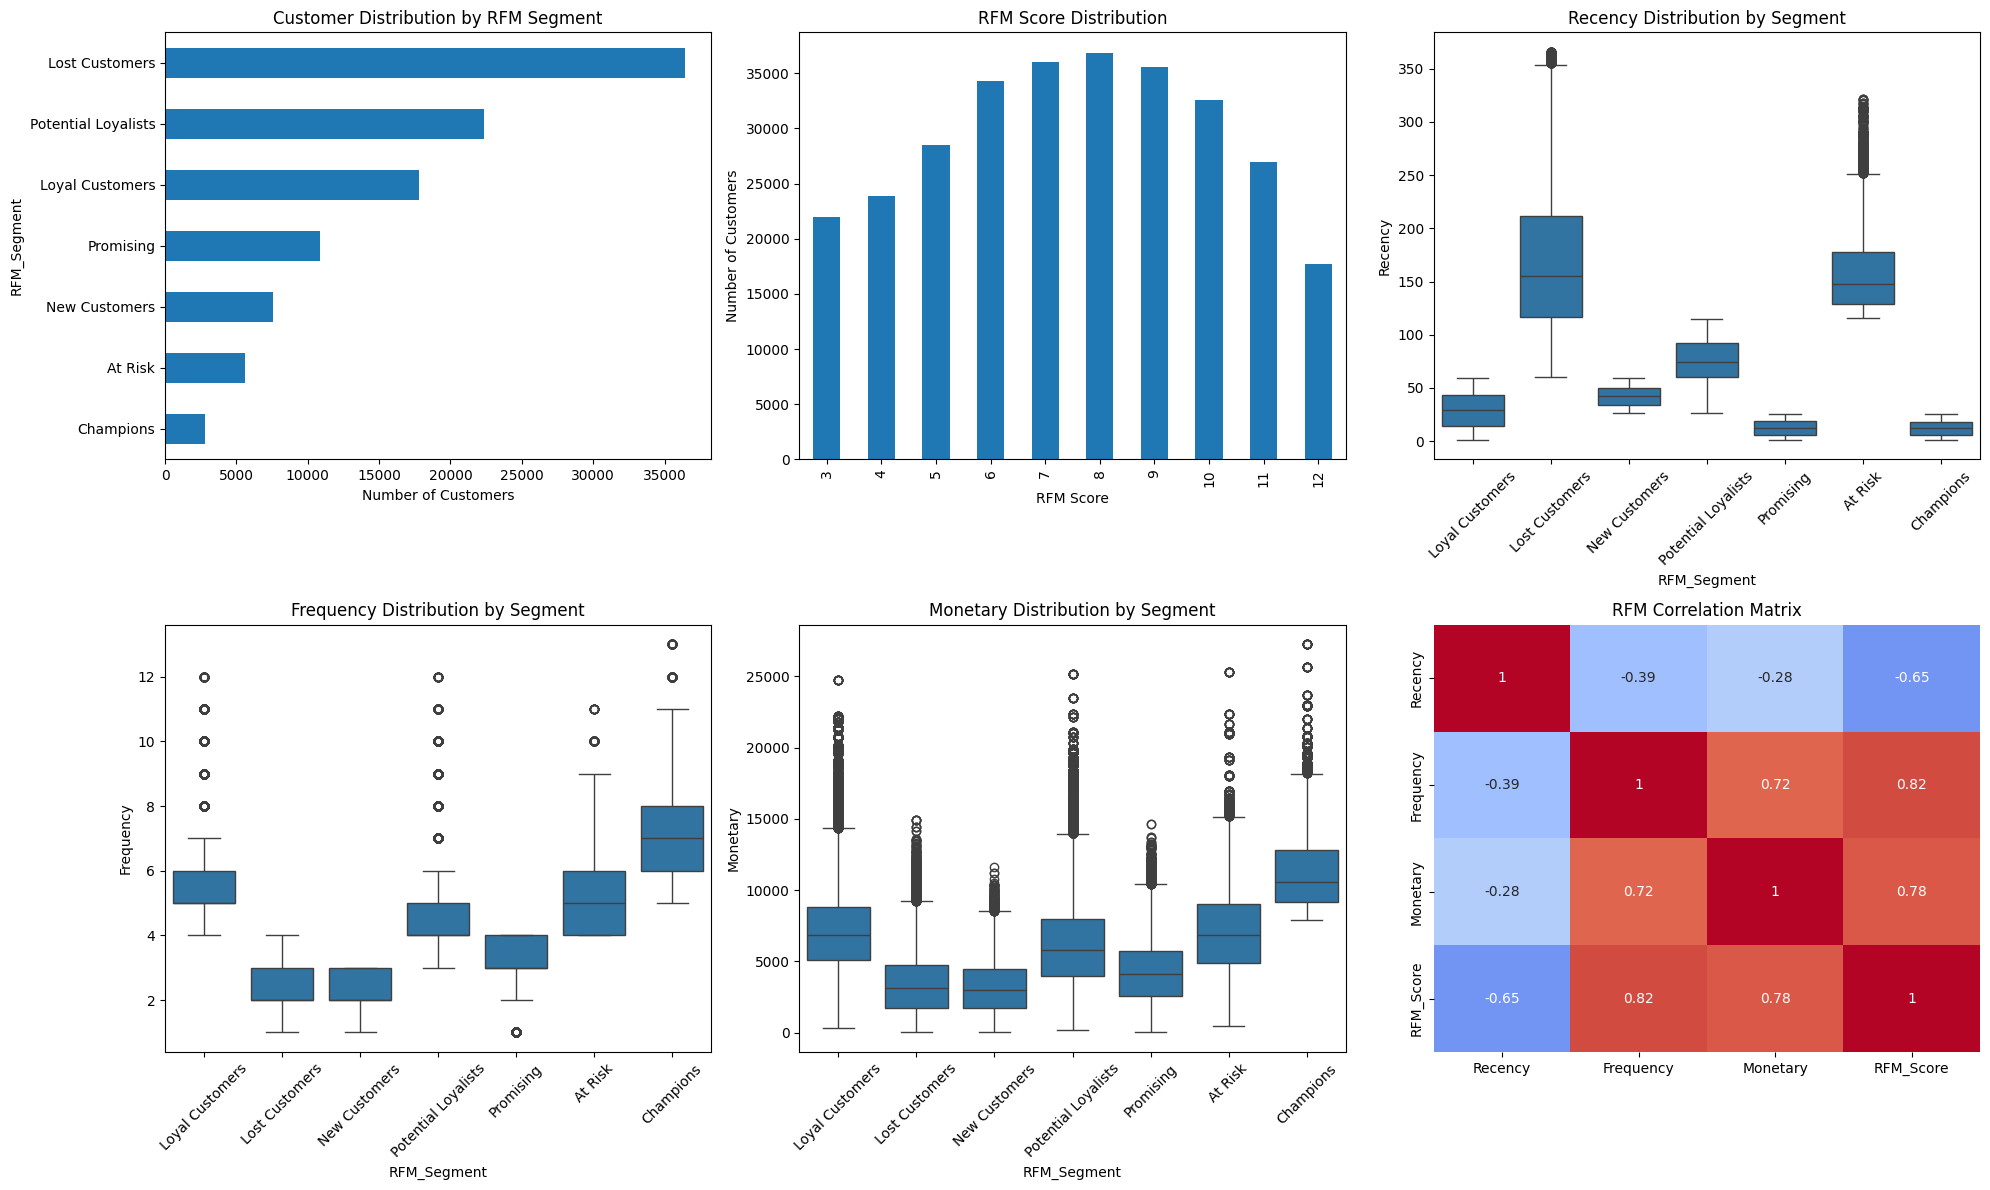

In [55]:
# RFM ANALYSIS
plt.figure(figsize=(20, 12))

# RFM Segment Distribution
plt.subplot(2, 3, 1)
segment_counts = df_with_rfm.groupby('RFM_Segment')['Customer_ID'].nunique().sort_values(ascending=True)
segment_counts.plot(kind='barh')
plt.title('Customer Distribution by RFM Segment')
plt.xlabel('Number of Customers')

# RFM Score Distribution
plt.subplot(2, 3, 2)
score_counts = df_with_rfm['RFM_Score'].value_counts().sort_index()
score_counts.plot(kind='bar')
plt.title('RFM Score Distribution')
plt.xlabel('RFM Score')
plt.ylabel('Number of Customers')

# Recency Distribution by Segment
plt.subplot(2, 3, 3)
sns.boxplot(data=df_with_rfm, x='RFM_Segment', y='Recency')
plt.title('Recency Distribution by Segment')
plt.xticks(rotation=45)

# Frequency Distribution by Segment
plt.subplot(2, 3, 4)
sns.boxplot(data=df_with_rfm, x='RFM_Segment', y='Frequency')
plt.title('Frequency Distribution by Segment')
plt.xticks(rotation=45)

# Monetary Distribution by Segment
plt.subplot(2, 3, 5)
sns.boxplot(data=df_with_rfm, x='RFM_Segment', y='Monetary')
plt.title('Monetary Distribution by Segment')
plt.xticks(rotation=45)

# RFM Correlation Heatmap
plt.subplot(2, 3, 6)
rfm_corr = df_with_rfm[['Recency', 'Frequency', 'Monetary', 'RFM_Score']].corr()
sns.heatmap(rfm_corr, annot=True, cmap='coolwarm', center=0,cbar=False)
plt.title('RFM Correlation Matrix')

plt.tight_layout()
plt.show()

## Inferential Statistics

In [57]:
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway

In [58]:
# Hypothesis 1: Is there a significant difference in spending between genders?
print("\nGender vs Total Amount (T-test):")
print("H0: No difference in spending between genders")
print("Ha: Significant difference in spending between genders")
male_spending = df_with_rfm[df_with_rfm['Gender'] == 'Male']['Total_Amount']
female_spending = df_with_rfm[df_with_rfm['Gender'] == 'Female']['Total_Amount']
t_stat, p_value = stats.ttest_ind(male_spending, female_spending, nan_policy='omit')
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")
print("Significant difference in spending between genders" if p_value < 0.05
      else "No difference in spending between genders")


Gender vs Total Amount (T-test):
H0: No difference in spending between genders
Ha: Significant difference in spending between genders
T-statistic: -0.2682, P-value: 0.7885
No difference in spending between genders


In [59]:
# Hypothesis 2: Is there a relationship between Customer Segment and Feedback?
print("Customer Segment vs Feedback (Chi-square):")
print("H0: No relationship between Customer Segment and Feedback")
print("Ha: Significant relationship between Customer Segment and Feedback")
contingency_table = pd.crosstab(df_with_rfm['Customer_Segment'], df_with_rfm['Feedback'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-square: {chi2:.4f}, P-value: {p_value:.4f}")
print("Significant relationship between Customer Segment and Feedback" if p_value < 0.05
      else "No relationship between Customer Segment and Feedback")

Customer Segment vs Feedback (Chi-square):
H0: No relationship between Customer Segment and Feedback
Ha: Significant relationship between Customer Segment and Feedback
Chi-square: 3582.8335, P-value: 0.0000
Significant relationship between Customer Segment and Feedback


In [60]:
# Hypothesis 3: Is there a difference in Ratings across Product Categories?
print("Product Category vs Ratings (ANOVA):")
print("H0: All product categories have equal mean ratings")
print("Ha: At least one product category has a different mean rating")
samp1 = df_with_rfm[df_with_rfm['Product_Category']=='Clothing']['Ratings']
samp2 = df_with_rfm[df_with_rfm['Product_Category']=='Electronics']['Ratings']
samp3 = df_with_rfm[df_with_rfm['Product_Category']=='Books']['Ratings']
samp4 = df_with_rfm[df_with_rfm['Product_Category']=='Home Decor']['Ratings']
samp5 = df_with_rfm[df_with_rfm['Product_Category']=='Grocery']['Ratings']
f_stat, p_value = f_oneway(samp1,samp2,samp3,samp4,samp5)
print(f"F-statistic: {f_stat:.4f}, P-value: {p_value:.4f}")
print("At least one product category has a different mean rating" if p_value < 0.05
      else "All product categories have equal mean ratings")

Product Category vs Ratings (ANOVA):
H0: All product categories have equal mean ratings
Ha: At least one product category has a different mean rating
F-statistic: 187.0618, P-value: 0.0000
At least one product category has a different mean rating


In [61]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
pairwise_tukeyhsd(df_with_rfm['Ratings'],df_with_rfm['Product_Category'],alpha=0.05).summary()

group1,group2,meandiff,p-adj,lower,upper,reject
Books,Clothing,-0.0074,0.8905,-0.0295,0.0146,False
Books,Electronics,0.1588,0.0,0.1381,0.1796,True
Books,Grocery,0.0713,0.0,0.0503,0.0923,True
Books,Home Decor,-0.0016,0.9996,-0.0237,0.0204,False
Clothing,Electronics,0.1663,0.0,0.1455,0.187,True
Clothing,Grocery,0.0787,0.0,0.0577,0.0997,True
Clothing,Home Decor,0.0058,0.9535,-0.0163,0.0278,False
Electronics,Grocery,-0.0875,0.0,-0.1072,-0.0679,True
Electronics,Home Decor,-0.1605,0.0,-0.1812,-0.1397,True
Grocery,Home Decor,-0.0729,0.0,-0.094,-0.0519,True


In [62]:
# Hypothesis 4: Correlation between Age and Total Amount
print("Age vs Total Amount (Pearson Correlation):")
print("H0: No correlation between Age and Total Amount")
print("Ha: Significant correlation between Age and Total Amount")
correlation, p_value = stats.pearsonr(df_with_rfm['Age'], df_with_rfm['Total_Amount'])
print(f"Correlation: {correlation:.4f}, P-value: {p_value:.4f}")
print("Significant correlation between Age and Total Amount" if p_value < 0.05 
      else "No correlation between Age and Total Amount")

Age vs Total Amount (Pearson Correlation):
H0: No correlation between Age and Total Amount
Ha: Significant correlation between Age and Total Amount
Correlation: 0.0224, P-value: 0.0000
Significant correlation between Age and Total Amount


## Feature Engineering

In [67]:
rating_feedback_df = df.groupby('Customer_ID').agg({
     'Ratings': 'mean',
     'Feedback': lambda x: x.mode().iloc[0]}).reset_index()
rating_feedback_df.columns = ['Customer_ID','Rating','FeedBack']

In [69]:
df_with_rfm = df_with_rfm.merge(rating_feedback_df, on='Customer_ID', how='left')

In [71]:
df_with_rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294250 entries, 0 to 294249
Data columns (total 40 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Transaction_ID    294250 non-null  float64       
 1   Customer_ID       294250 non-null  object        
 2   Name              294250 non-null  object        
 3   Email             294250 non-null  object        
 4   Phone             294250 non-null  float64       
 5   Address           294250 non-null  object        
 6   City              294250 non-null  object        
 7   State             294250 non-null  object        
 8   Zipcode           294250 non-null  float64       
 9   Country           294250 non-null  object        
 10  Age               294250 non-null  float64       
 11  Gender            294250 non-null  object        
 12  Income            294250 non-null  object        
 13  Customer_Segment  294250 non-null  object        
 14  Date

In [73]:
df_with_rfm.drop(['Transaction_ID','Name','Email','Phone','Address','City','State','Zipcode','products','Date','Year',
                 'Month','Time','Total_Purchases','Amount','Total_Amount','Product_Category','Product_Brand','Product_Type',
                 'Feedback','Shipping_Method','Payment_Method','Order_Status','Ratings','products','Gender','Country','R_Score','F_Score','M_Score',
                 'Customer_Segment','RFM_Segment'],
                 axis=1,inplace=True)

In [75]:
df_with_rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294250 entries, 0 to 294249
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Customer_ID  294250 non-null  object 
 1   Age          294250 non-null  float64
 2   Income       294250 non-null  object 
 3   Recency      294250 non-null  int64  
 4   Frequency    294250 non-null  int64  
 5   Monetary     294250 non-null  float64
 6   RFM_Score    294250 non-null  int32  
 7   Rating       294250 non-null  float64
 8   FeedBack     294250 non-null  object 
dtypes: float64(3), int32(1), int64(2), object(3)
memory usage: 19.1+ MB


In [77]:
df_with_rfm.drop_duplicates(subset='Customer_ID',inplace=True)

In [79]:
df_with_rfm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 86503 entries, 0 to 291934
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer_ID  86503 non-null  object 
 1   Age          86503 non-null  float64
 2   Income       86503 non-null  object 
 3   Recency      86503 non-null  int64  
 4   Frequency    86503 non-null  int64  
 5   Monetary     86503 non-null  float64
 6   RFM_Score    86503 non-null  int32  
 7   Rating       86503 non-null  float64
 8   FeedBack     86503 non-null  object 
dtypes: float64(3), int32(1), int64(2), object(3)
memory usage: 6.3+ MB


In [81]:
df_with_rfm.drop('Customer_ID',axis=1,inplace=True)

## Encoding

In [83]:
from sklearn.preprocessing import OrdinalEncoder

In [85]:
o = OrdinalEncoder(categories=[['Low','Medium','High']]) 
df_with_rfm['Income'] = o.fit_transform(df_with_rfm[['Income']])

In [89]:
o = OrdinalEncoder(categories=[['Bad','Average','Good','Excellent']]) 
df_with_rfm['FeedBack'] = o.fit_transform(df_with_rfm[['FeedBack']])

## Scaling

In [91]:
from sklearn.preprocessing import MinMaxScaler
df_with_rfm_scaled = df_with_rfm.copy()

In [93]:
for col in df_with_rfm_scaled.columns:
    mm = MinMaxScaler()
    df_with_rfm_scaled[col] = mm.fit_transform(df_with_rfm_scaled[[col]])

In [95]:
df_with_rfm_scaled.head()

,Age,Income,Recency,Frequency,Monetary,RFM_Score,Rating,FeedBack
0,0.057692,0.0,0.063014,0.333333,0.237730,0.777778,0.600000,0.333333
1,0.019231,0.0,0.000000,0.333333,0.149780,0.666667,0.450000,0.666667
2,0.576923,0.0,0.347945,0.250000,0.269014,0.333333,0.750000,1.000000
3,0.730769,1.0,0.136986,0.166667,0.291018,0.555556,0.583333,0.333333
4,0.076923,0.0,0.073973,0.166667,0.048633,0.222222,0.083333,0.000000


In [97]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF

In [99]:
vf = [VIF(df_with_rfm_scaled.values,i) for i in range(df_with_rfm_scaled.shape[1])]
vif_df = pd.DataFrame(vf,index=df_with_rfm_scaled.columns,columns=['VIF'])
vif_df.sort_values(by='VIF',ascending=False)

,VIF
RFM_Score,18.818040
Rating,13.104777
Frequency,11.284325
Monetary,11.015410
FeedBack,8.320516
Recency,3.684920
Income,2.592902
Age,1.874880


### There seems to be some multicollinearity. Hence, we will apply PCA.

# PCA

In [101]:
from sklearn.decomposition import PCA

In [103]:
pca = PCA(random_state=10)
pca.fit_transform(df_with_rfm_scaled)

array([[-1.48566297e-04,  3.16733766e-01, -6.42613155e-01, ...,
         1.85682380e-01, -2.37677459e-02, -8.32331259e-02],
       [ 1.96174869e-01,  2.36291173e-01, -5.67469777e-01, ...,
        -1.11951658e-01,  4.10008087e-02, -8.41148082e-02],
       [ 5.42266681e-01, -3.59339104e-01, -3.18842618e-01, ...,
        -3.32120612e-03,  2.26584511e-02,  9.22589860e-02],
       ...,
       [ 1.14329898e-01, -6.38745936e-01, -2.47300450e-01, ...,
         1.23780942e-01, -3.22294496e-02, -1.96418478e-02],
       [ 2.71157145e-01, -3.72284027e-01, -3.94796115e-01, ...,
         8.25055612e-02, -6.58997288e-02, -9.32137645e-02],
       [ 5.77552562e-01, -6.44516146e-01, -2.05965619e-01, ...,
         1.70425771e-01, -3.61616436e-02, -2.14281917e-02]])

In [105]:
np.cumsum(pca.explained_variance_ratio_)

array([0.30625462, 0.57320247, 0.80468271, 0.9003265 , 0.95522272,
       0.98542868, 0.99401909, 1.        ])

In [107]:
pca1 = PCA(random_state=10,n_components=5)
components = pca1.fit_transform(df_with_rfm_scaled)

In [109]:
pca_df = pd.DataFrame(components,columns=['PCA1','PCA2','PCA3','PCA4','PCA5'])
pca_df

,PCA1,PCA2,PCA3,PCA4,PCA5
0,-0.000149,0.316734,-0.642613,-0.049911,0.000322
1,0.196175,0.236291,-0.567470,-0.131016,-0.095186
2,0.542267,-0.359339,-0.318843,0.233036,0.135727
3,-0.180297,0.276687,0.357534,0.643135,0.045071
4,-0.641734,-0.059431,-0.604705,-0.071920,-0.226516
...,...,...,...,...,...
86498,0.470999,-0.645977,0.305027,0.415373,-0.077480
86499,-0.863767,-0.544754,0.050203,0.281650,0.318738
86500,0.114330,-0.638746,-0.247300,-0.115732,-0.069266
86501,0.271157,-0.372284,-0.394796,0.558001,-0.250900


# Clustering

In [112]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

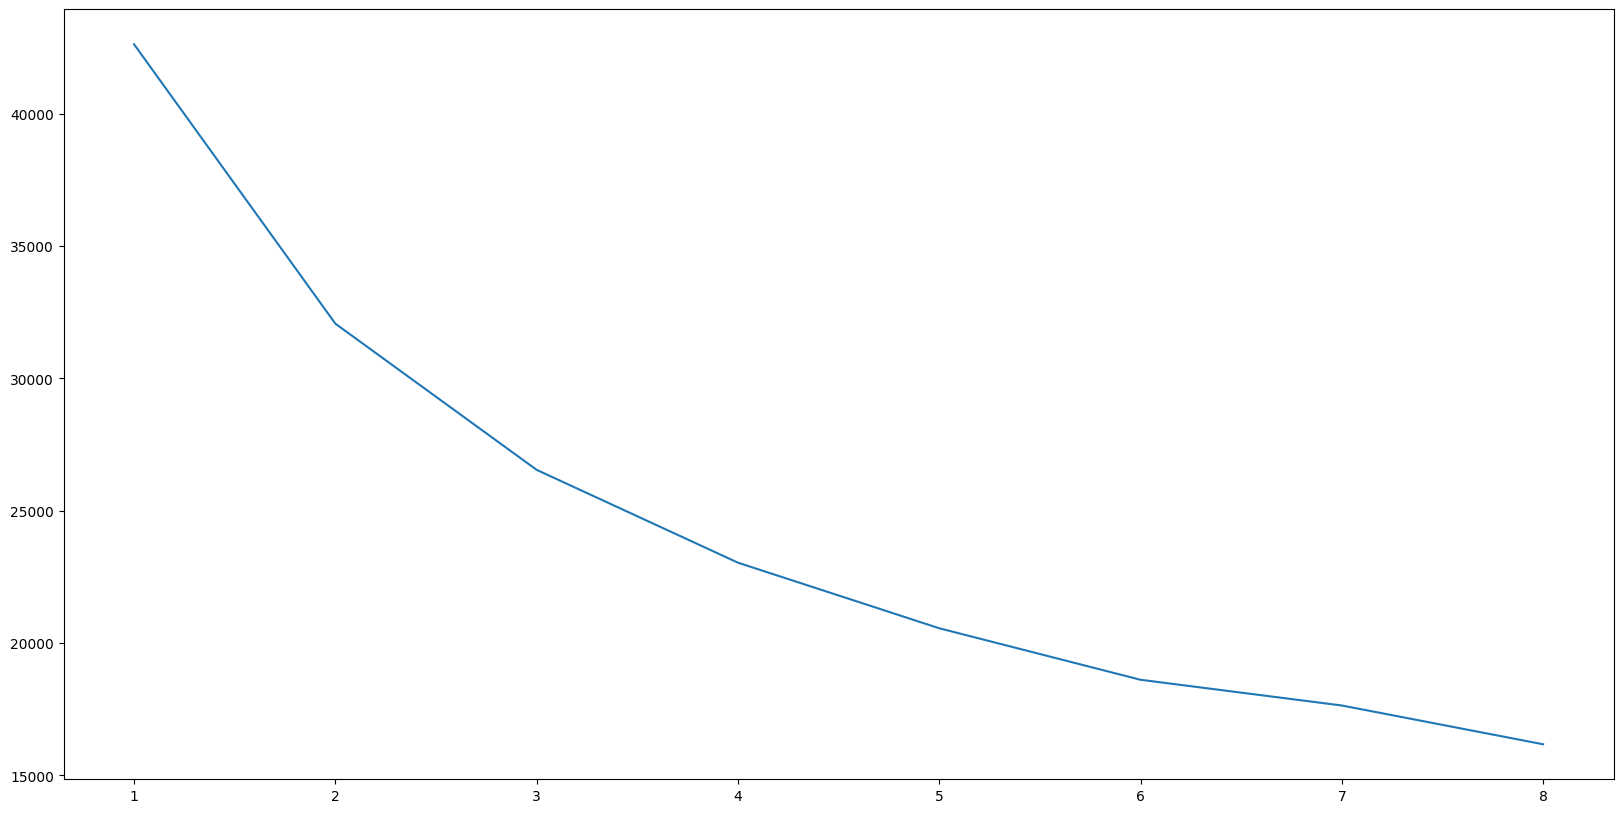

In [114]:
wcss = []
k = [1,2,3,4,5,6,7,8]
for i in k:
    model = KMeans(n_clusters=i,random_state=10)
    model.fit(pca_df)
    wcss.append(model.inertia_)
plt.plot(k,wcss)
plt.show()

In [116]:
model = KMeans(n_clusters=3,random_state=10)
predict = model.fit_predict(pca_df)

In [118]:
# WCSS
print(model.inertia_)

26542.979771647653


In [120]:
df_with_rfm['Cluster'] = predict

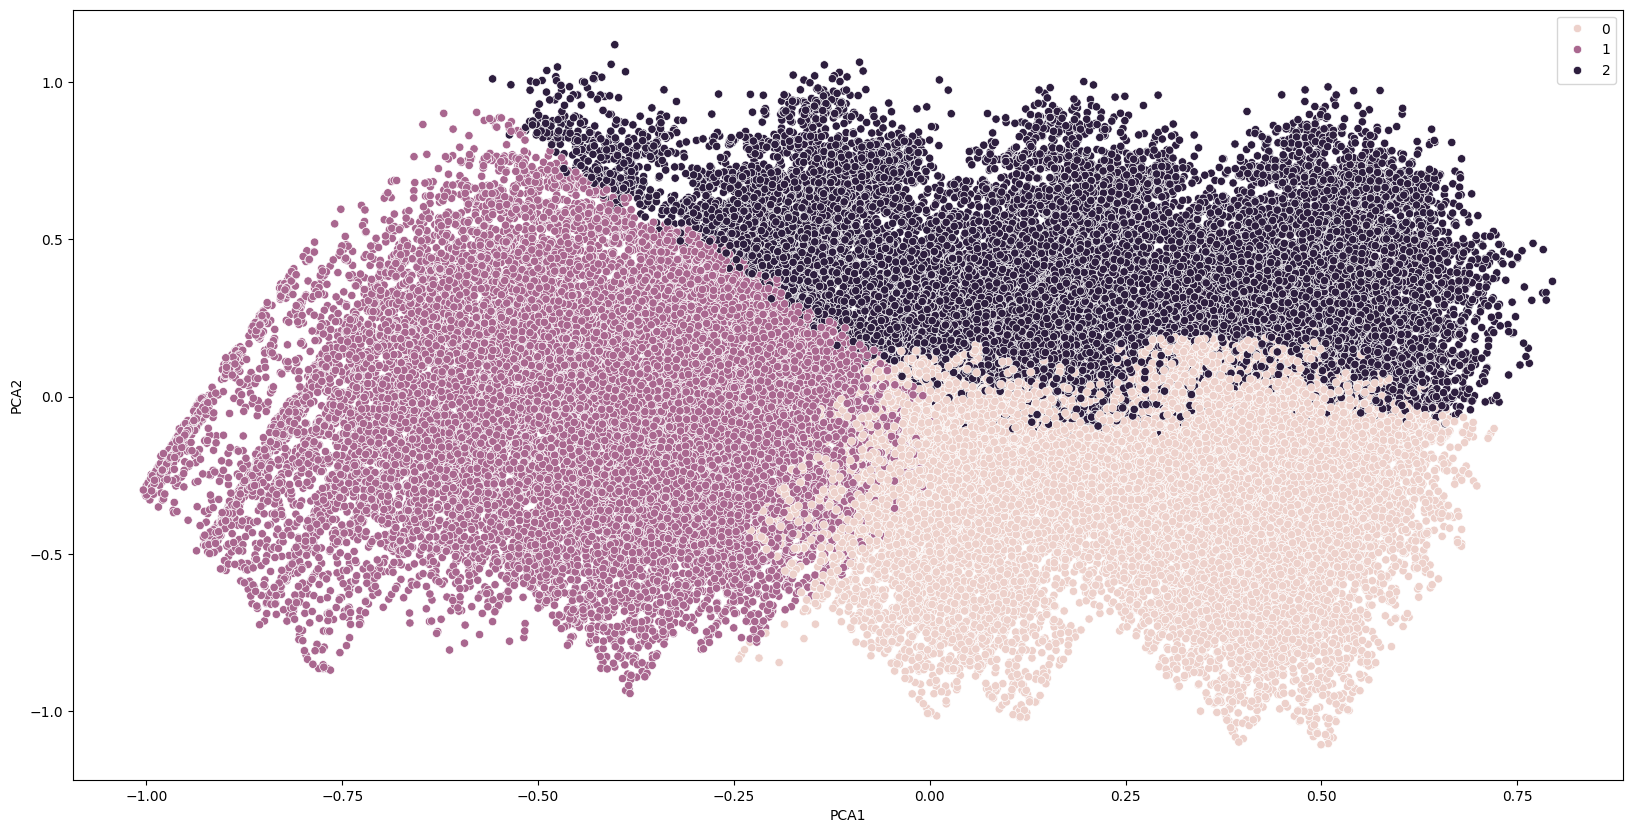

In [122]:
sns.scatterplot(x=pca_df['PCA1'],y=pca_df['PCA2'],hue=predict)
plt.show()

In [124]:
df_with_rfm[df_with_rfm['Cluster']==0].describe()

,Age,Income,Recency,Frequency,Monetary,RFM_Score,Rating,FeedBack,Cluster
count,27545.000000,27545.000000,27545.000000,27545.000000,27545.000000,27545.000000,27545.000000,27545.000000,27545.0
mean,33.100127,0.854093,136.284770,2.412017,2983.234883,4.568669,3.866086,2.640334,0.0
std,13.755927,0.717267,88.881337,1.135674,2001.152027,1.357394,0.594740,0.481422,0.0
min,18.000000,0.000000,1.000000,1.000000,11.802737,3.000000,2.250000,1.000000,0.0
25%,21.000000,0.000000,65.000000,1.000000,1399.004101,3.000000,3.500000,2.000000,0.0
50%,26.000000,1.000000,122.000000,2.000000,2704.035582,4.000000,4.000000,3.000000,0.0
75%,46.000000,1.000000,195.000000,3.000000,4261.967138,6.000000,4.000000,3.000000,0.0
max,70.000000,2.000000,366.000000,7.000000,15052.055203,9.000000,5.000000,3.000000,0.0


In [126]:
df_with_rfm[df_with_rfm['Cluster']==1].describe()

,Age,Income,Recency,Frequency,Monetary,RFM_Score,Rating,FeedBack,Cluster
count,32454.000000,32454.000000,32454.000000,32454.000000,32454.000000,32454.000000,32454.000000,32454.000000,32454.0
mean,27.930178,0.992420,111.585598,2.805633,3695.121397,5.289024,2.459855,0.649658,1.0
std,12.083168,0.707752,84.867024,1.219203,2352.118195,1.846954,0.655141,0.490774,0.0
min,18.000000,0.000000,1.000000,1.000000,10.304530,3.000000,1.000000,0.000000,1.0
25%,20.000000,0.000000,43.000000,2.000000,1882.977415,4.000000,2.000000,0.000000,1.0
50%,22.000000,1.000000,92.000000,3.000000,3378.563313,5.000000,2.500000,1.000000,1.0
75%,34.000000,1.000000,162.000000,3.000000,5074.353750,7.000000,3.000000,1.000000,1.0
max,70.000000,2.000000,366.000000,11.000000,22368.392990,12.000000,3.666667,2.000000,1.0


In [128]:
df_with_rfm[df_with_rfm['Cluster']==2].describe()

,Age,Income,Recency,Frequency,Monetary,RFM_Score,Rating,FeedBack,Cluster
count,26504.000000,26504.000000,26504.000000,26504.000000,26504.000000,26504.000000,26504.000000,26504.000000,26504.0
mean,24.721174,1.040975,43.290069,5.159863,7559.242059,9.173710,3.295809,2.189217,2.0
std,8.771456,0.651623,38.451021,1.458912,3039.791720,1.634674,0.518532,0.809568,0.0
min,18.000000,0.000000,1.000000,1.000000,149.478087,5.000000,1.500000,0.000000,2.0
25%,20.000000,1.000000,14.000000,4.000000,5434.575257,8.000000,3.000000,2.000000,2.0
50%,22.000000,1.000000,32.000000,5.000000,7196.015897,9.000000,3.250000,2.000000,2.0
75%,24.000000,1.000000,61.000000,6.000000,9332.094341,10.000000,3.666667,3.000000,2.0
max,70.000000,2.000000,269.000000,13.000000,27247.457685,12.000000,5.000000,3.000000,2.0


# Customer Segmentation Analysis

## Cluster 0: The Inactive Customers

### Profile
- **Segment Size**: Medium segment (27,545 customers)
- **Demographics**: Moderate age and income

### RFM Characteristics
- **Recency**: Very High (Inactive)
- **Frequency**: Low
- **Monetary Value**: Low

### Satisfaction
- **Ratings**: High
- **Feedback**: Positive

### Inference
These are satisfied customers who are now inactive. They are a key **"win-back" opportunity**.

---

## Cluster 1: At-Risk Customers

### Profile
- **Segment Size**: Largest segment (32,454 customers)
- **Demographics**: Youngest segment with mixed income

### RFM Characteristics
- **Recency**: High (At-Risk)
- **Frequency**: Low-Moderate
- **Monetary Value**: Moderate

### Satisfaction
- **Ratings**: Low
- **Feedback**: Poor

### Inference
This segment is **actively dissatisfied** and at high risk of churning completely. Their poor experience is the likely cause of their infrequent purchases.

---

## Cluster 2: The Champions / High-Value Customers

### Profile
- **Segment Size**: Smallest (26,504 customers) but most valuable segment
- **Demographics**: Young, high-income segment

### RFM Characteristics
- **Recency**: Excellent (Recent)
- **Frequency**: High
- **Monetary Value**: High

### Satisfaction
- **Ratings**: Good
- **Feedback**: Positive

### Inference
Your **most valuable and loyal customers**. They are responsible for a **disproportionate share of revenue**.

## Summary Table

| Cluster | Segment Name | Loyalty Status | Recency | Frequency | Monetary | Satisfaction | Priority |
|---------|--------------|----------------|---------|-----------|----------|--------------|----------|
| **0** | Inactive | Lapsed | Inactive   | Low | Low | High | Medium |
| **1** | At-Risk | At-Risk | At-Risk   | Low-Moderate | Moderate | Low | High |
| **2** | Champions | Loyal | Excellent   | High | High | Good | Highest |

# Business Recommendations & Action Plans

## Cluster 0: The Inactive Customers

### Business Recommendations
**Primary Goal**: Reactivate lapsed customers and rebuild purchase frequency  
**Budget Priority**: Low-Medium  
**Expected ROI**: Medium-High  

### Action Plan
- Send "We Miss You" emails with special comeback discounts
- Implement reactivation discounts (25-30% off first purchase back)
- Share "What You've Missed" content highlighting new products/improvements
- Use personalized outreach based on their previous purchase history
- Create time-limited exclusive offers for returning customers
- Give extra loyalty points for returning

---

## Cluster 1: At-Risk Customers

### Business Recommendations
**Primary Goal**: Service recovery and trust rebuilding to prevent churn  
**Budget Priority**: High  
**Expected ROI**: High 

### Action Plan
- Improve satisfaction to build brand loyalty
- Conduct surveys to understand their main issues
- Quickly resolve complaints with a dedicated response team
- Offer money-back guarantees or problem-solving discounts
- Create simple guides to improve their experience
- Assign dedicated relationship managers for high-value at-risk customers

---

## Cluster 2: The Champions / High-Value Customers

### Business Recommendations
**Primary Goal**: Increase lifetime value and transform into brand advocates  
**Budget Priority**: Highest  
**Expected ROI**: Highest  

### Action Plan
- Create VIP program with special benefits and early access
- Start referral program with premium rewards
- Invite to exclusive events and product previews
- Provide personalized product recommendations
- Send surprise gifts and recognition rewards
- Offer beta testing opportunities for new products

---

## Summary

| Segment | Primary Focus | Key Metrics to Track |
|---------|---------------|---------------------|
| **Champions** | Retention & Advocacy | Lifetime Value, Referral Rate, Repeat Purchase Rate |
| **At-Risk** | Churn Prevention | Retention Rate, Satisfaction Scores, Complaint Resolution |
| **Inactive** | Reactivation | Reactivation Rate, Win-back Conversion, Re-engagement |